In [1]:
import numpy as np
import matplotlib.pyplot as plt
from funcs import neural_model
from funcs import metrics
from funcs import joint_model

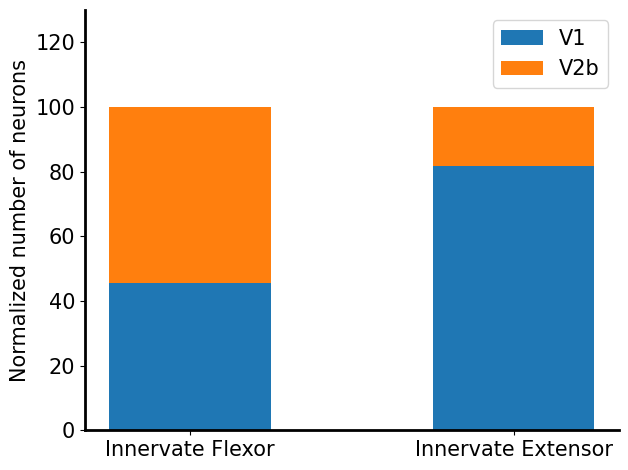

In [2]:
# bar plot of number
V1F = 0.4545
V1X = 0.8181
V2bF = 0.5455
V2bX = 0.1819
labels = ('Innervate Flexor','Innervate Extensor'
)
weight_counts = {
    "V1": np.array([V1F,V1X])*100,
    "V2b": np.array([V2bF,V2bX])*100,
}
width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(2)

for boolean, weight_count in weight_counts.items():
    p = ax.bar(labels, weight_count, width, label=boolean, bottom=bottom)
    bottom += weight_count

ax.legend(loc="upper right", fontsize=15)

# axs[ind].set_xlim([2,6])
ax.set_ylim([0.0, 130])
# ax.legend(fontsize = 9,ncols=2)
width = 2
ax.spines['bottom'].set_linewidth(width)
ax.spines['left'].set_linewidth(width)
ax.spines[['right','top']].set_visible(False)

ax.set_ylabel('Normalized number of neurons',fontsize = 15)
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.tight_layout()


In [3]:
EF = neural_model.WC_Neuron(Ja = 140.0, Jdp = 110.0, s0=0.011,   
                   taus = 3.9615, taua = 166.80, taudp = 1.8765, taur = 250.2, 
                   x0 = 0.9223, u0 = 0.1, uFlag = 1,UU = 0.03)
IF = neural_model.WC_Neuron(Ja = 180.0, Jdp = 0.0, s0=0.012,
               taus = 5.4210, taua = 62.55, taudp = 1000.0, taur = 225.0, 
               x0 = 0.4796, u0 = 0.4, uFlag = 0)
EX = neural_model.WC_Neuron(Ja = 140.0, Jdp = 110.0, s0=0.01,
               taus = 3.9615, taua = 166.80, taudp = 1.8765, taur = 250.2, 
               x0 = 0.9223, u0 = 0.1, uFlag = 1,UU = 0.03)
IX = neural_model.WC_Neuron(Ja = 180.0, Jdp = 0.0, s0=0.01,
               taus = 5.4210, taua = 62.55, taudp = 1000.0, taur = 225.0, 
               x0 = 0.4796, u0 = 0.4, uFlag = 0)
MF = neural_model.WC_Neuron(Ja = 140.0, Jdp = 0.0,
               taus = 5.4210, taua = 500.4, taudp = 1000.0, taur = 225.0, 
               x0 = 0.4796, u0 = 0.4, uFlag = 0)
MX = neural_model.WC_Neuron(Ja = 140.0, Jdp = 0.0, 
               taus = 5.4210, taua = 500.4, taudp = 1000.0, taur = 225.0, 
               x0 = 0.4796, u0 = 0.4, uFlag = 0)
ListWCNeuron = [EF, IF, EX, IX, MF, MX]

[[   0.        -41.40246     2.236     -25.345166    0.          0.      ]
 [  17.888       0.          0.        -18.10369     0.          0.      ]
 [   2.236     -48.30287     0.        -21.724428    0.          0.      ]
 [   0.        -34.50205    17.888       0.          0.          0.      ]
 [  67.08        0.          0.       -108.62214     0.          0.      ]
 [   0.       -207.0123     67.08        0.          0.          0.      ]]


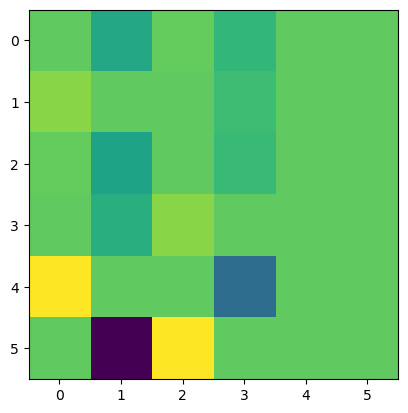

In [4]:
infor = {'regular':None, 'regularasym':'V1scale=0.8','irregular':'V1scale=Escale=0.2',
        '100cocontraction':'V1scale=Escale=0.05','atonia':'V1_inp_scale=2'}

name = 'irregular'

Jee2 = 0
Jie2 = 52 
Jei2 = 66 
Jii2 = 0 
Jee = 6.5 
Jii = 55
Jei = 77 

Jme=195 
Jmi=330 

V3prop = 0.2

Escale = 1.0*(1-V3prop)+V3prop
V1scale = 1.0
V2bscale = 1
Iscale = 1

V1F = 0.4545 # 
V1X = 0.8181 # 
V2bF = 0.5455 # 
V2bX = 0.1819 # 

V1_inp_scale =  0.0
V2b_inp_scale = 0.0

# 
if name == 'regularasym':
    V1scale = 0.8
if name == 'irregular':
    V1scale = 0.18
    Escale = 0.18*(1-V3prop)+V3prop
if name == '100cocontraction':
    V1scale = 0.05
    Escale = 0.05*(1-V3prop)+V3prop
if name == 'atonia':
    V1_inp_scale = 2.0

I0I = 0.3
I0E = 0.6

IscaleX = (V1scale* V1X+ V2bscale*V2bX)
IscaleF = (V1scale* V1F+ V2bscale*V2bF)


I0I_F = I0I + V1_inp_scale*V1F+V2b_inp_scale*V2bF
I0I_X = I0I + V1_inp_scale*V1X+V2b_inp_scale*V2bX


ListWCNeuron = [EF, IF, EX, IX, MF, MX]

ConnMat = np.array([[Escale*Jee2, IscaleF*-Jei2, Escale*Jee, IscaleX*-Jei, 0.0, 0.0],
                   [Escale*Jie2, IscaleF*-Jii2, 0.0, IscaleX*-Jii, 0.0, 0.0],
                   [Escale*Jee, IscaleF*-Jei, Escale*Jee2, IscaleX*-Jei2, 0.0, 0.0],
                   [0.0, IscaleF*-Jii, Escale*Jie2, IscaleX*-Jii2, 0.0, 0.0],
                   [Escale * Jme, 0.0, 0.0, -IscaleX*Jmi, 0.0, 0.0],
                   [0.0, -IscaleF*Jmi,Escale * Jme, 0.0, 0.0, 0.0]])

plt.imshow(ConnMat)
print(ConnMat)

In [5]:
FinalNN = neural_model.WC_NN(ListWCNeuron,ConnMat, beta = 0.011, dt = 0.1)

In [6]:
T = 10000
FinalNN.init_dynamics(T)
inp_arr = [I0E, I0I_F, I0E, I0I_X, 0.0, 0.0]
for i in range(FinalNN.Npts):
    FinalNN.update(inp_arr)
    FinalNN.record(i)
freqF,ccrateF,irflagF  = metrics.peak_cal_contract(FinalNN.marr[4],FinalNN.marr[4],FinalNN.marr[5],0.2,
                                      int(FinalNN.Npts/2),scale= 0.1,dt=0.1)
freqX,ccrateX,irflagX  = metrics.peak_cal_contract(FinalNN.marr[5],FinalNN.marr[5],FinalNN.marr[4],0.2,
                                      int(FinalNN.Npts/2),scale= 0.1,dt=0.1)
print(freqF,freqX,ccrateF,ccrateX)

2.6283092803211314 2.358713086140202 0.9285714285714286 0.8571428571428571


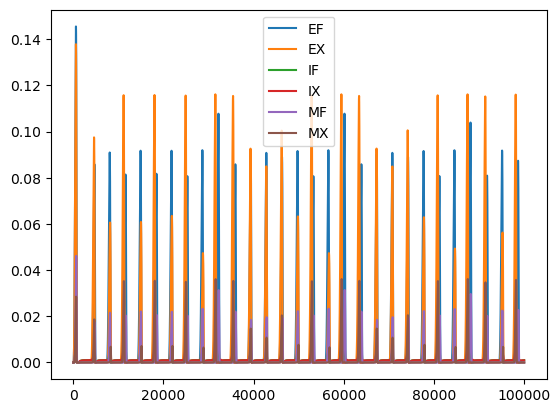

In [7]:
# plot
plt.plot(FinalNN.marr[0],label='EF') 
plt.plot(FinalNN.marr[2],label='EX') 
plt.plot(FinalNN.marr[1],label='IF') 
plt.plot(FinalNN.marr[3],label='IX') 
plt.plot(FinalNN.marr[4],label='MF') 
plt.plot(FinalNN.marr[5],label='MX') 
plt.legend()

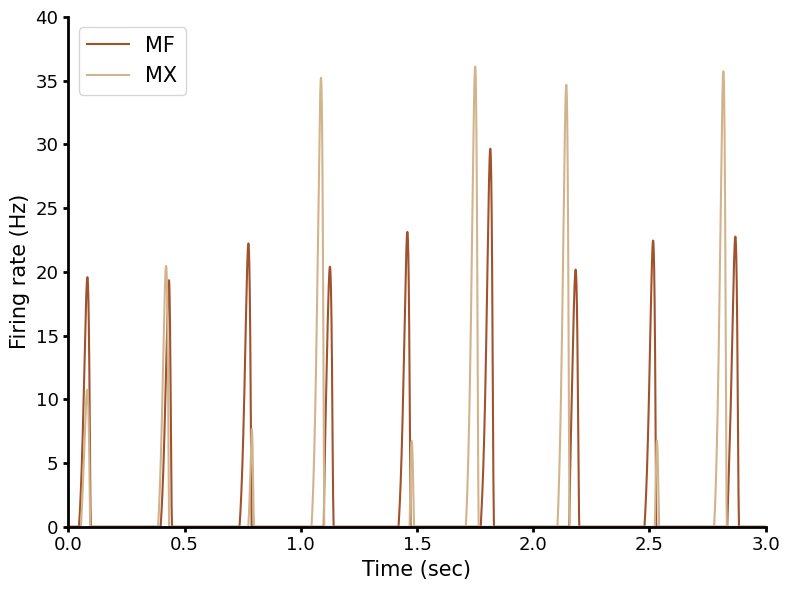

In [8]:
fig,ax = plt.subplots(figsize=(8,6))
dt=0.1
tt = np.linspace(0, T, FinalNN.Npts)
plotran = int(3000/dt)

ax.plot(tt[-plotran:]/1000-7,FinalNN.marr[4][-plotran:]*1000, label = 'MF', color = 'sienna')
ax.plot(tt[-plotran:]/1000-7,FinalNN.marr[5][-plotran:]*1000, label = 'MX',color = 'tan')
ax.set_xlabel('Time (sec)',fontsize =15)
ax.set_ylabel('Firing rate (Hz)', fontsize = 15)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['bottom','left']:
    ax.spines[spine].set_linewidth(2) 
# ax.set_xticks(np.linspace(0,4,5))
ax.xaxis.set_major_formatter('{x:.1f}')
ax.xaxis.set_tick_params(width=2,labelsize=13)
ax.yaxis.set_tick_params(width=2,labelsize=13)
plt.ylim([0.0, 40])
plt.xlim([0.0, 3.0])
plt.legend(fontsize = 15)
plt.tight_layout()

In [9]:
T_plot = 3000
dt=0.1
fac = 1000/18/3.0
time_sim, x_mat = joint_model.Jointmodel(np.tanh(FinalNN.marr[4][-int(T_plot/dt):]*fac), 
                             np.tanh(FinalNN.marr[5][-int(T_plot/dt):]*fac),dt=0.1)

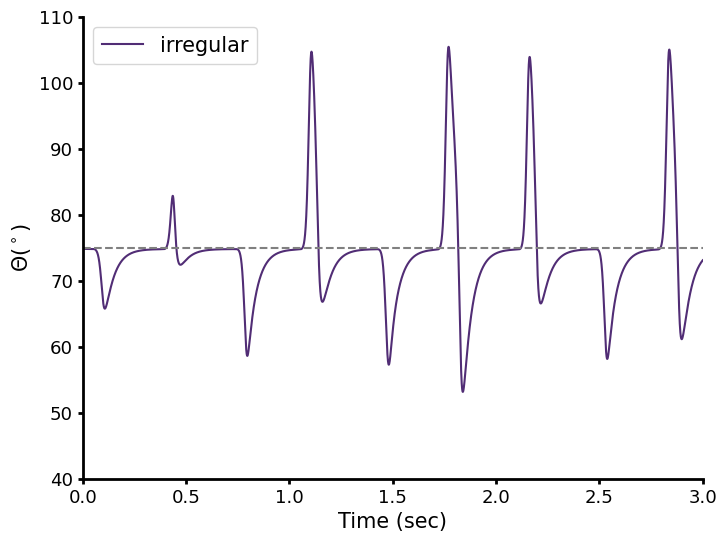

In [10]:
# setMyPlot((8,6))
fig,ax = plt.subplots(figsize=(8,6))
T_plot = 3000

ax.plot(time_sim[-int(T_plot/dt):],np.rad2deg(x_mat[:,4])[-int(T_plot/dt):],color='#512d75',label=name)

ax.set_xlabel('Time (sec)',fontsize =15)
ax.set_ylabel('$\Theta(^\circ)$',fontsize=15)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['bottom','left']:
    ax.spines[spine].set_linewidth(2) 
ax.hlines(75,0,3,linestyles ='dashed',color='grey')
# ax.set_xticks(np.linspace(0,4,5))
ax.xaxis.set_major_formatter('{x:.1f}')
ax.xaxis.set_tick_params(width=2,labelsize=13)
ax.yaxis.set_tick_params(width=2,labelsize=13)
plt.ylim([40,110])
plt.xlim([0,3])
plt.legend(fontsize=15)